# TCGA

The Cancer Genome Atlas (TCGA) is a comprehensive resource that catalogs genomic alterations across 33 different human cancers. Unlike cell lines, TCGA analyzes primary tumor samples directly from patients, providing a detailed view of the tumor's molecular landscape within its native tissue environment. The dataset includes genomic, epigenomic, transcriptomic, and proteomic data but for our analysis we focus on genomic data, in particular on mRNA data and mutations data.

## Contents of the notebook
In this notebook, we analyse and prepare the downloaded data for use in classifier training. The data was downloaded from cBioportal by querying TCGA. We then selected a subset of cancer studies, downloading the following files for each study:

data_mutations.txt : Dataframe containing information of all the mutated genes in the samples;
data_mrna_seq_rpkm.txt: expression data with samples as columns and genes as rows;

We analyse samples and genes to filter outliers and understand the distribution. We then visualise the data using dimensionality reduction techniques. Finally, we prepare the dataset that will be used to build the classifiers.

In [1]:
import pandas as pd 
import numpy as np 
import os 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.manifold import TSNE
from scipy.stats import skew, kurtosis
from sklearn.decomposition import PCA
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()

## Auxiliary Functions

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.stats import skew, kurtosis

# ----------------------
# Violin Plot of Metrics
# ----------------------
def plot_violin_metrics(data, axis):
    """
    Plot violin plots of QC metrics either across genes or samples.
    
    Parameters:
        data (pd.DataFrame): Gene expression matrix (genes x samples)
        axis (int): 0 for sample-wise, 1 for gene-wise
    """
    is_gene_axis = axis == 1
    metrics = {
        "Total Counts": data.sum(axis=axis),
        "Mean": data.mean(axis=axis),
        "Median": data.median(axis=axis),
        "Standard Deviation": data.std(axis=axis),
        "Coefficient of Variation": data.std(axis=axis) / data.mean(axis=axis),
        "Total Features": data.astype(bool).sum(axis=axis)
    }

    fig, ax = plt.subplots(1, len(metrics), figsize=(25, 12))
    colors = ['firebrick', 'steelblue', 'orange', 'darkgreen', 'indigo', 'silver']
    labels = list(metrics.keys())

    for i, (label, values) in enumerate(metrics.items()):
        sns.violinplot(y=values.reset_index(drop=True), ax=ax[i], color=colors[i])
        scope = "Genes" if is_gene_axis else "Samples"
        ax[i].set_title(f"{label} Across {scope}")
        ax[i].set_xlabel('')
        ax[i].grid(True)
        print(f'Max {label.lower()}: {values.max():.2f} - Min: {values.min():.2f} = Range: {(values.max() - values.min()):.2f}')

    plt.tight_layout()
    plt.show()

# ------------------------------------
# Skewness and Kurtosis Distribution
# ------------------------------------
def plot_skewness_kurtosis(data, axis):
    """
    Plot bar plots of skewness and kurtosis across genes or samples.
    
    Parameters:
        data (pd.DataFrame): Gene expression matrix
        axis (int): 0 for sample-wise, 1 for gene-wise
    """
    target = "Sample" if axis == 0 else "Gene"
    skew_vals = data.apply(skew, axis=axis)
    kurt_vals = data.apply(kurtosis, axis=axis)

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.bar(range(len(skew_vals)), skew_vals.values, color='mediumpurple')
    plt.title(f"Skewness of Expression per {target}")
    plt.xlabel(f"{target} Index")
    plt.ylabel("Skewness")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.bar(range(len(kurt_vals)), kurt_vals.values, color='darkorange')
    plt.title(f"Excess Kurtosis per {target}")
    plt.xlabel(f"{target} Index")
    plt.ylabel("Kurtosis")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# ---------------------
# Correlation Heatmap
# ---------------------
def heatmap_plot(title, data, samples):
    """
    Plot correlation heatmap across a list of sample IDs.

    Parameters:
        title (str): Title of the heatmap
        data (pd.DataFrame): Expression matrix
        samples (list): Sample IDs to include
    """
    plt.figure(figsize=(10, 8))
    plt.title(title)
    sns.heatmap(data.loc[:, samples].corr(), cmap='viridis', fmt='.01f')
    plt.tight_layout()
    plt.show()
    print(f"Number of samples plotted: {len(samples)} x {len(samples)}")

# ------------------------------
# PCA and t-SNE Visualization
# ------------------------------
def plot_PCA_tsne(data, mutated_samples, non_mutated_samples, title):
    """
    Plot PCA and t-SNE for mutated and non-mutated samples.

    Parameters:
        data (pd.DataFrame): Expression matrix (genes x samples)
        mutated_samples (list): Sample IDs labeled as mutated
        non_mutated_samples (list): Sample IDs labeled as non-mutated
        title (str): Figure title
    """
    labels = ['Mutated'] * len(mutated_samples) + ['Non_Mutated'] * len(non_mutated_samples)
    label_map = {'Mutated': 0, 'Non_Mutated': 1}
    colors = [label_map[l] for l in labels]
    X = data[mutated_samples + non_mutated_samples].T.to_numpy()

    pca_result = PCA(n_components=2).fit_transform(X)
    tsne_result = TSNE(n_components=2, random_state=42).fit_transform(X)

    plt.figure(figsize=(14, 6))

    # PCA Plot
    plt.subplot(1, 2, 1)
    plt.scatter(pca_result[:, 0], pca_result[:, 1], c=colors, cmap='viridis')
    plt.title("PCA: Mutated vs Non-Mutated")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)

    # t-SNE Plot
    plt.subplot(1, 2, 2)
    plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=colors, cmap='viridis')
    plt.title("t-SNE: Mutated vs Non-Mutated")
    plt.xlabel("tSNE1")
    plt.ylabel("tSNE2")
    plt.grid(True)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------
# Violin Plot of Mitochondrial Gene Percentage
# ---------------------------------------------
def plot_MT_percent_violinplot(data):
    """
    Plot the percentage of mitochondrial gene expression per sample.

    Parameters:
        data (pd.DataFrame): Gene expression matrix (genes x samples)
    """
    total_expr = data.sum(axis=0)
    mt_expr = data.loc[data.index.str.startswith("MT-")].sum(axis=0)
    mt_percent = (mt_expr / total_expr) * 100

    plt.figure(figsize=(12, 6))
    sns.violinplot(y=mt_percent, color='skyblue')
    plt.title("Violin Plot of Mitochondrial Gene Expression (%) per Sample")
    plt.ylabel("Mitochondrial % of Total RPKM")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [3]:
result_list = [] # to collect resulting dataframes 

df = pd.read_table('../DATA/tcga/data_mutations.txt', delimiter='\t', comment='#')

df = df[df['Hugo_Symbol'] == 'TP53']

# Keeping only columns that are relevat for our study
final_df = df[['Hugo_Symbol', 'Tumor_Sample_Barcode','Variant_Classification','Variant_Type']]   
#final_df['Tumor_Name'] = ''

final_df.to_csv('../DATA/tcga/mutation_data_complete.csv', index=False)


file_path = '../DATA/tcga/data_mrna_seq_fpkm.txt'

df = pd.read_csv(file_path, sep='\t', index_col=0)
df.index = df.index.str.strip()

# If there are multiple rows concerning the same gene we average the results 
df = df.groupby(df.index).mean()

df.to_csv('../DATA/tcga/mrna_data.csv')


In [4]:
# Visualize all different types of variant classification 
print('Variant classification unique values: ',final_df['Variant_Classification'].unique().tolist())
print('Variant type unique values: ',final_df['Variant_Type'].unique().tolist() )

Variant classification unique values:  ['Nonsense_Mutation', 'Missense_Mutation', 'In_Frame_Del', 'Frame_Shift_Del', 'Splice_Site', 'Frame_Shift_Ins', 'Splice_Region', 'In_Frame_Ins', 'Silent']
Variant type unique values:  ['SNP', 'DEL', 'INS', 'DNP']


In [5]:
import pandas as pd

# --------- Load and Clean mRNA Data ---------
mRNA_path = '../DATA/tcga/mrna_data.csv'

# Load expression data
mRNA_data = pd.read_csv(mRNA_path)

# Set gene names as index
mRNA_data.set_index('Hugo_Symbol', inplace=True)

# Drop the first column if it's repeated index or metadata
if mRNA_data.columns[0] == mRNA_data.columns.name:
    mRNA_data = mRNA_data[mRNA_data.columns[1:]]

# Drop samples (columns) with any missing values
if mRNA_data.isna().sum().any():
    print("There are NaN values in mRNA data. Dropping them...")
    mRNA_data = mRNA_data.dropna(axis=1)

print("mRNA data shape after cleaning:", mRNA_data.shape)

# --------- Load and Filter Mutation Data (TP53) ---------
mut_path = '../DATA/tcga/mutation_data_complete.csv'

# Load mutation dataset
mut_data = pd.read_csv(mut_path)

# Keep only sample barcode and mutation type
mut_data = mut_data[['Tumor_Sample_Barcode', 'Variant_Type']]
mut_data.set_index('Tumor_Sample_Barcode', inplace=True)

# Remove samples with inconsistent mutation annotations (e.g., multiple variant types)
variant_check = mut_data.groupby(mut_data.index)["Variant_Type"].nunique()
consistent_samples = variant_check[variant_check == 1].index
inconsistent_samples = variant_check[variant_check != 1].index

mut_data = mut_data.loc[consistent_samples]

# Drop inconsistent samples from mRNA data if present
mRNA_data = mRNA_data.drop(columns=[sample for sample in inconsistent_samples if sample in mRNA_data.columns])

# Remove duplicate sample entries (same Variant_Type) — keep the first occurrence
mut_data = mut_data[~mut_data.index.duplicated(keep='first')]

# --------- Add Wild-Type (WT) Labels ---------
all_samples = set(mRNA_data.columns)
mutated_samples = set(mut_data.index)
wt_samples = all_samples - mutated_samples

# Create WT labels for non-mutated samples
wt_df = pd.DataFrame(index=list(wt_samples))
wt_df['Variant_Type'] = 'WT'

# Combine WT and Mutated samples into one mutation dataframe
mut_data = pd.concat([mut_data, wt_df])

# Align order with mRNA columns
mut_data = mut_data.loc[mRNA_data.columns]

# --------- Final Summary ---------
print("Final sample counts by mutation type:")
print(mut_data['Variant_Type'].value_counts())

# Now you have:
# - `mRNA_data`: gene expression (genes x samples)
# - `mut_data`: mutation status (samples x 1)


mRNA data shape after cleaning: (55851, 1210)
Final sample counts by mutation type:
Variant_Type
WT     803
SNP    331
DEL     46
INS     18
DNP      5
Name: count, dtype: int64


In [6]:
# We want to take samples for which we have both the mrna expression and the mutation

common = list(set(mRNA_data.columns) & set(mut_data.index))
mRNA_data= mRNA_data[common] # This contains mRNA data
merged_mutation = mut_data.loc[common] # This contains mutation type

merged_mutation.to_csv('../DATA/tcga/final_mutation_data.csv',index=True)
mRNA_data.to_csv('../DATA/tcga/final_mrna_data.csv',index=True)

### Dimensionality Reduction Using Biological Prior

To reduce the dimensionality of the expression data, a biologically guided approach is applied. Specifically, the analysis focuses on a subset of genes known to be **transcriptional targets of TP53**, as listed in the [TP53 Target Gene Database](https://tp53.cancer.gov/target_genes).

The expression levels of these genes are evaluated to determine whether they differ significantly between **TP53-mutated** and **non-mutated** samples.  
If substantial variation is observed, these genes can serve as an informative feature set for downstream classification tasks—offering a more interpretable and potentially more robust model.


In [7]:
tp53_targets = [
    'CDKN1A', 'ABCA12', 'NTPCR', 'PGPEP1', 'RNF19B', 'LCE1E', 'EPN3', 'SCN4B', 'ARVCF', 'FCHO2',
    'PANK2', 'TMEM8B', 'RRM2B', 'ANKRA2', 'ORAI3', 'PLCL2', 'SAC3D1', 'LIMK2', 'FBXO32', 'SCRIB',
    'BHLHE40', 'FCHSD2', 'PAQR7', 'TP53', 'MDM2', 'CCNG1', 'PRKAB1', 'PMAIP1', 'SYTL1', 'LRP1',
    'FHL2', 'SEMA3B', 'BMP7', 'FLRT2', 'PCBP4', 'TP53I11', 'SUSD6', 'CYFIP2', 'PTP4A1', 'PRDM1',
    'TNFRSF10A', 'MCC', 'HES2', 'SLC25A45', 'BORCS7', 'GBE1', 'PERP', 'TRAK1', 'GDF15', 'DRAM1',
    'SESN2', 'RAP2B', 'TNFRSF10D', 'NUPR1', 'KCNN4', 'SLC44A5', 'BTBD10', 'GPC1', 'PLLP', 'TRIP6',
    'BTG2', 'FBXO22', 'SLC30A1', 'RRAD', 'TSPAN11', 'PARD6G', 'KLHDC7A', 'SLC4A11', 'BTG3', 'HES1',
    'POU3F1', 'TSGA10', 'DDB2', 'ISCU', 'SPATA18', 'ZNF219', 'VWCE', 'PHPT1', 'LMNA', 'SLC9A1',
    'C17orf89', 'HRAS', 'PPFIBP1', 'UNC5B', 'GADD45A', 'PHLDA3', 'TGFA', 'ZNF337', 'DDIT4', 'PIDD1',
    'MLF2', 'STAT3', 'CAPN2', 'HSD17B3', 'PPM1J', 'UQCC1', 'PLK3', 'SERPINB5', 'TLR3', 'ACTA2',
    'RAD51C', 'PML', 'MR1', 'STK17A', 'CASP6', 'ICOSLG', 'PPP4R3A', 'VDR', 'TIGAR', 'SERTAD1',
    'TM7SF3', 'EDN2', 'SERPINE1', 'PTPRE', 'MYO6', 'STX6', 'CATSPERG', 'IGFBP7', 'PTAFR', 'YPEL3',
    'RPS27L', 'TRAF4', 'TMEM68', 'ALOX5', 'TNFAIP8', 'PVRL4', 'NEFL', 'TP73', 'CAV1', 'IL1B',
    'RALGDS', 'ZNF195', 'TNFRSF10B', 'TRIM22', 'WDR63', 'ARHGEF3', 'TSKU', 'RETSAT', 'NKAIN4',
    'TRIM32', 'CCNK', 'ISYNA1', 'RBM38', 'ZNF385A', 'TRIAP1', 'CES2', 'ZNF561', 'CERS5', 'PCNA',
    'REV3L', 'PCLO', 'TRIM38', 'CFLAR', 'JAG1', 'RGL1', 'ZNF488', 'ZMAT3', 'CMBL', 'ZNF79',
    'DDR1', 'ACYP2', 'RNASE7', 'PDE4C', 'TRIM5', 'CGB7', 'KRT8', 'RGS20', 'BAX', 'FBXW7',
    'ASCC3', 'DHRS3', 'APAF1', 'SFN', 'PGAP1', 'TYMSOS', 'CHST14', 'KSR1', 'RHOC', 'PGF',
    'HSPA4L', 'ACER2', 'DUSP14', 'APOBEC3H', 'TNFRSF10C', 'PLCXD2', 'AKAP9', 'COBLL1', 'LACC1',
    'RPS19', 'POLH', 'KITLG', 'ANXA4', 'E2F7', 'BCL2L1', 'TRIML2', 'PLEKHF1', 'CCDC51', 'CPEB2',
    'LPXN', 'SARS', 'PPM1D', 'SLC12A4', 'APOBEC3C', 'EPS8L2', 'BCL6', 'VCAN', 'PLTP', 'CDH8',
    'CPSF4', 'LRPAP1', 'SCIN', 'SULF2', 'ATF3', 'ASTN2', 'FAM210B', 'BLCAP', 'ADCK3', 'PLXNB1',
    'DUSP11', 'DNAJB2', 'MFAP3L', 'SCN3B', 'XPC', 'BBC3', 'CD82', 'GLS2', 'C17orf82', 'AK3',
    'PLXNB2', 'GCC2', 'DOCK8', 'MKNK2', 'SDC4', 'AEN', 'CCDC90B', 'CDIP1', 'GPX1', 'COL7A1',
    'ALDH1A3', 'PRKAB2', 'METTL8', 'DUSP5', 'MON2', 'SDPR', 'BLOC1S2', 'DYRK3', 'CPE', 'GRHL3',
    'CPEB4', 'BBS2', 'PRKX', 'PPP1R3C', 'DUSP7', 'MRPL49', 'SMAD3', 'FAS', 'EDA2R', 'CSF1',
    'HHAT', 'CSNK1G1', 'BTG1', 'PRODH', 'STEAP3', 'EBI3', 'MYBPHL', 'SNX2', 'GPR87', 'EPHA2',
    'DCP1B', 'IGDCC4', 'DGKA', 'CEL', 'PTPRU', 'ABHD4', 'EFNB1', 'MYLK', 'SOCS4', 'NINJ1',
    'FAM13C', 'ENC1', 'IKBIP', 'FAM49A', 'CLCA2', 'RGMA', 'ABTB2', 'EI24', 'MYOF', 'TAB3',
    'PLK2', 'FAM198B', 'FOSL1', 'LAPTM5', 'FAM84B', 'CLDN1', 'RGS16', 'ADGRG1', 'EML2', 'NFKBIA',
    'TCAIM', 'PSTPIP2', 'FAM212B', 'FUCA1', 'MAST4', 'GNAI1', 'CLP1', 'RND3', 'AIFM2', 'ENPP2',
    'NHLH2', 'TEP1', 'SESN1', 'FDXR', 'IER5', 'MICALL1', 'INPP1', 'CROT', 'RNF144B', 'AMOTL1',
    'ETV7', 'NLRP1', 'TET2', 'TP53I3', 'LIF', 'PADI4', 'NOTCH1', 'ITGA3', 'CYP4F3', 'S100A2',
    'AMZ2', 'FAM196A', 'NYNRIN', 'TEX9', 'TP53INP1', 'NADSYN1', 'PANK1', 'RABGGTA', 'KRT15',
    'DAPK1', 'SCN2A', 'ARC', 'FAM98C', 'P3H2', 'TMEM63B'
]

# Get the list of genes present in mRNA_data
genes_in_data = mRNA_data.index.tolist()

#Filter the TP53 target genes to include only the ones in the data
tp53_targets_final=list(set(tp53_targets).intersection(genes_in_data))

# Filter the mRNA expression to keep only target genes
mRNA_data_tp53_targets = mRNA_data.loc[tp53_targets_final]

print("Number of genes in the filtered gene expression data:", len(mRNA_data_tp53_targets))

# Now I want to separate samples based on mutation status: 
mutated_samples = merged_mutation[merged_mutation['Variant_Type'].isin(['DEL', 'SNP', 'INS'])].index
non_mutated_samples = merged_mutation[merged_mutation['Variant_Type'] == 'WT'].index

# Extract gene expression for two dataframes based on mutation status
# Since the sample_ids are columns in mRNA_data, we filter by column names
mutated_expression = mRNA_data[mutated_samples]
non_mutated_expression = mRNA_data[non_mutated_samples]

# Check the size of the filtered data
print(f"Mutated samples shape: {mutated_expression.shape}")
print(f"Non-mutated samples shape: {non_mutated_expression.shape}")

Number of genes in the filtered gene expression data: 335
Mutated samples shape: (55851, 395)
Non-mutated samples shape: (55851, 803)


## Sample analysis

In [8]:
# Shape of mRNA
print(f'Number of genes: {len(mRNA_data.index)}\nNumber of samples: {len(mRNA_data.columns)}')
print(f'Zero entries: {(mRNA_data == 0).sum().sum()}') 
print("The sparsity of the data is due to the fact that the technique used to measure the expression is bulk RNAseq")


Number of genes: 55851
Number of samples: 1203
Zero entries: 28785531
The sparsity of the data is due to the fact that the technique used to measure the expression is bulk RNAseq


Max total counts: 4252383.31 - Min: 221125.11 = Range: 4031258.20
Max mean: 76.14 - Min: 3.96 = Range: 72.18
Max median: 0.82 - Min: 0.00 = Range: 0.82
Max standard deviation: 9591.48 - Min: 26.98 = Range: 9564.50
Max coefficient of variation: 125.97 - Min: 6.62 = Range: 119.36
Max total features: 51945.00 - Min: 20701.00 = Range: 31244.00


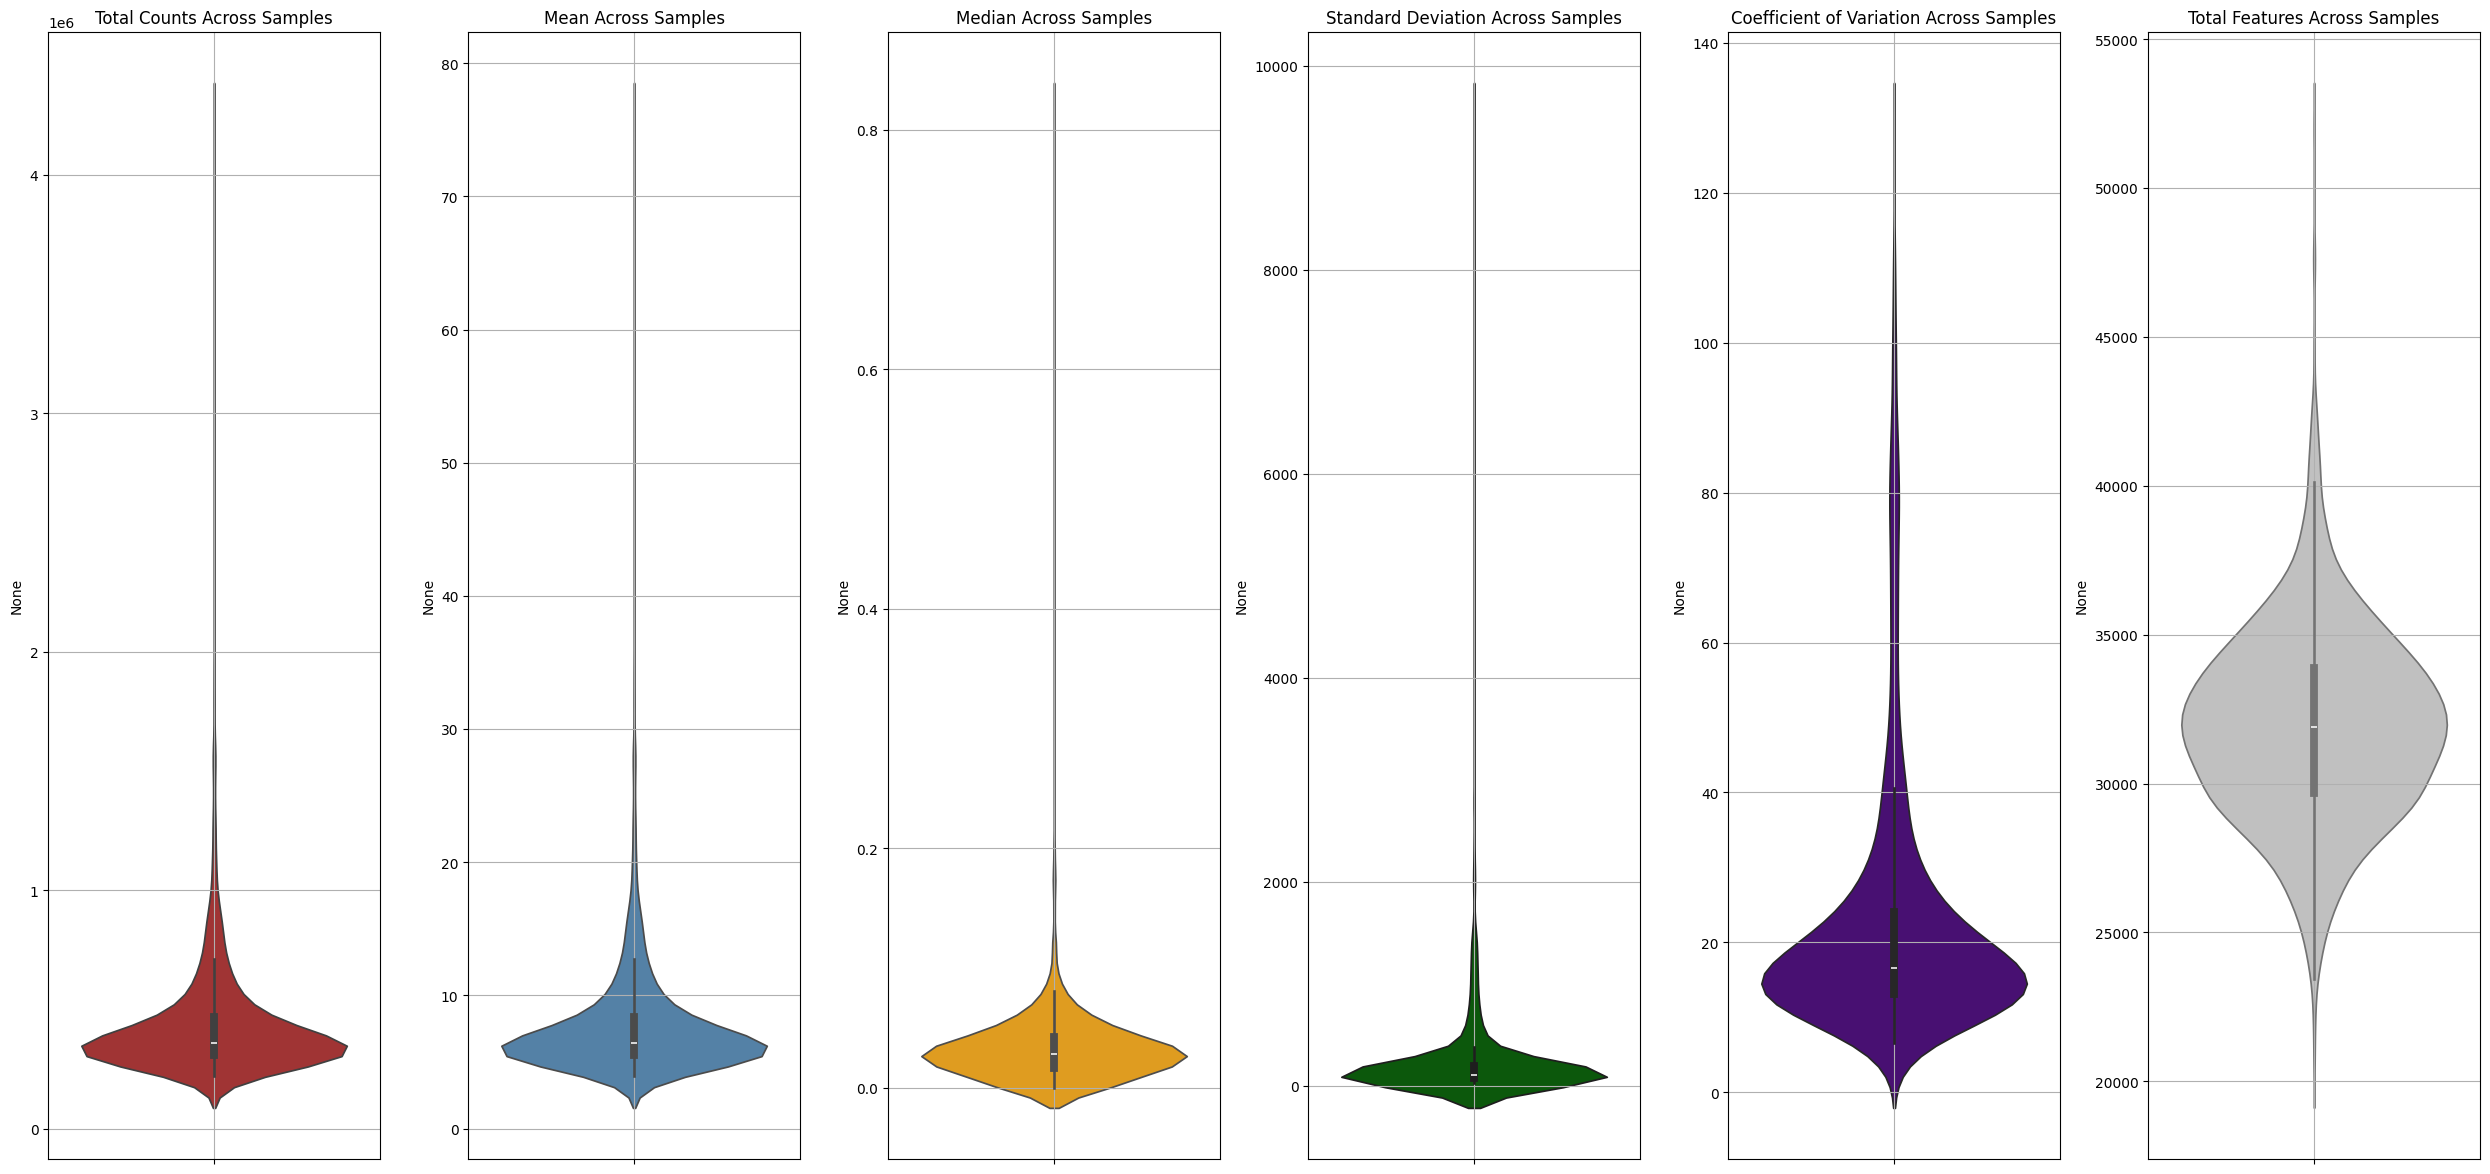

In [9]:
#Violin metrics across sample 
plot_violin_metrics(mRNA_data,axis = 0)

In [10]:
corr_matrix_micro = mRNA_data.corr()

In [11]:
print('-----mRNA data matrix-----')
print('Minimum correlation between samples:',corr_matrix_micro.describe().loc['min'].min())
print('Minimum mean correlation between samples:',corr_matrix_micro.describe().loc['mean'].min())

-----mRNA data matrix-----
Minimum correlation between samples: 0.0010921323216801276
Minimum mean correlation between samples: 0.06338340175719509


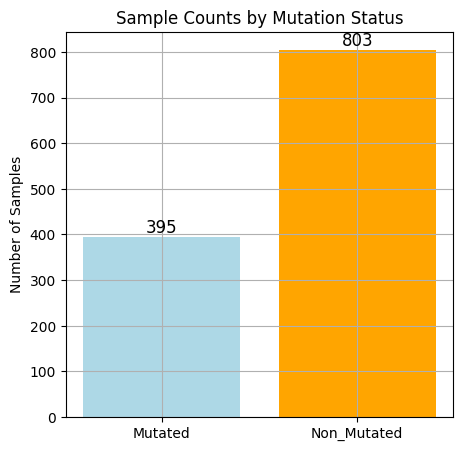

In [12]:
# See mutated distribution
counts = [len(mutated_samples), len(non_mutated_samples)]

plt.figure(figsize = (5,5))
plt.bar(x=['Mutated', 'Non_Mutated'], height=counts, 
                            color=['lightblue', 'orange'])

# Add text labels on top of each bar
for i, count in enumerate(counts):
    plt.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=12)

plt.grid(True)
plt.ylabel("Number of Samples")
plt.title("Sample Counts by Mutation Status")
plt.show()

### Correlation Structure Within Sample Classes

This section visualizes the correlation structure within a subset of the data by randomly selecting 100 **mutated** and 100 **non-mutated** samples. The goal is to assess whether the **intra-class correlations** are strong and distinct enough to be visually apparent.

Specifically, the analysis compares the correlation values computed **within each class** (mutated or non-mutated) against those obtained from the **entire dataset**, in order to determine whether class-specific expression patterns emerge.


In [13]:
# Extracting a random sample of mutated and non mutated data
random_samples_mut_100 = np.random.choice(mutated_samples,size = 100)
random_samples_non_mut_100 = np.random.choice(non_mutated_samples,size = 100)

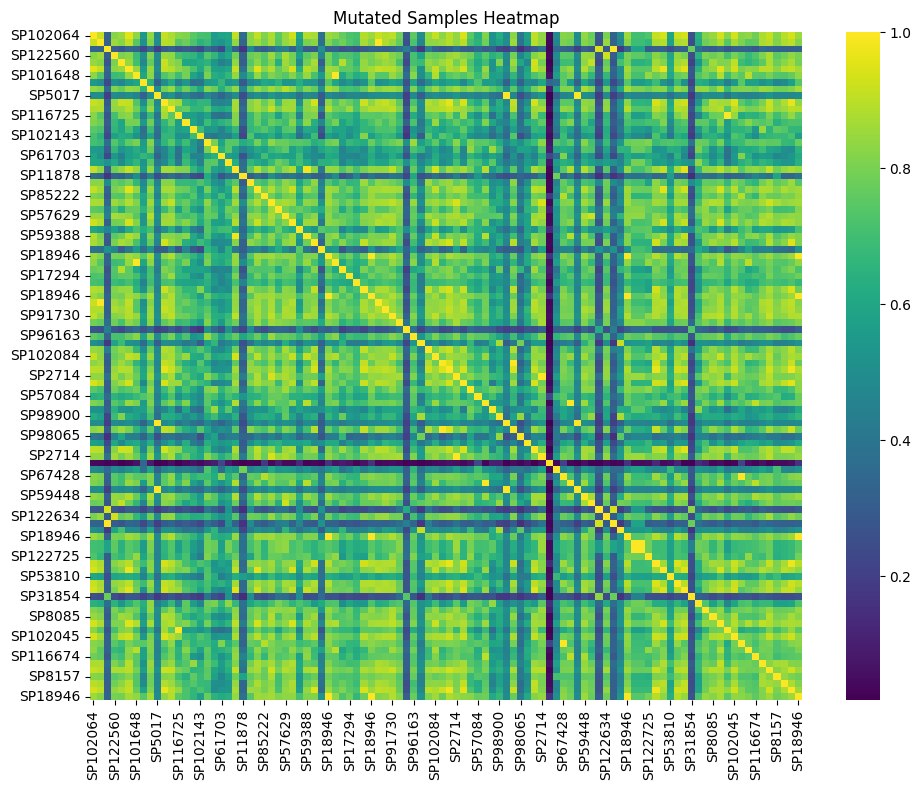

Number of samples plotted: 100 x 100


In [14]:
heatmap_plot(title = 'Mutated Samples Heatmap',data=mRNA_data,samples = random_samples_mut_100)

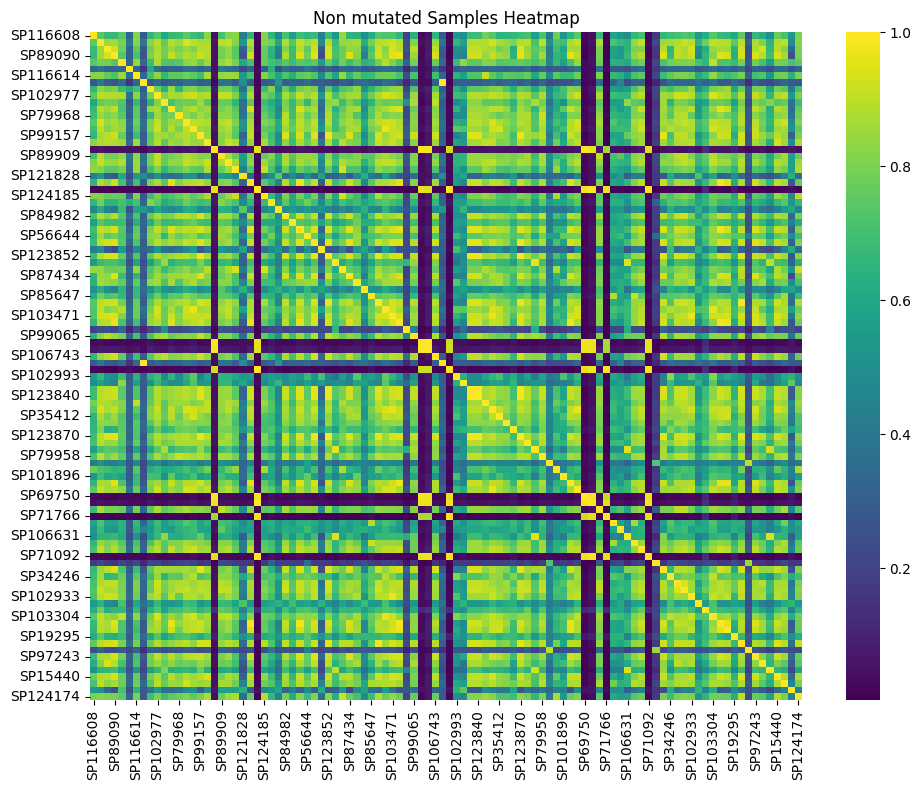

Number of samples plotted: 100 x 100


In [15]:
heatmap_plot(title = 'Non mutated Samples Heatmap',data=mRNA_data,samples = random_samples_non_mut_100)

In [16]:
# --- Correlation Analysis by Mutation Status ---

def print_min_correlation_stats(group_name, sample_ids, data):
    corr_matrix = data.loc[:, sample_ids].corr()
    stats = corr_matrix.describe()

    min_corr = stats.loc['min'].min()
    min_mean_corr = stats.loc['mean'].min()

    print(f"---- {group_name} Samples ----")
    print(f"1) Minimum pairwise correlation: {min_corr:.4f}")
    print(f"2) Minimum average correlation per sample: {min_mean_corr:.4f}\n")

# Mutated samples
print_min_correlation_stats("Mutated", mutated_samples, mRNA_data)

# Non-mutated samples
print_min_correlation_stats("Non-Mutated", non_mutated_samples, mRNA_data)


---- Mutated Samples ----
1) Minimum pairwise correlation: 0.0052
2) Minimum average correlation per sample: 0.0317

---- Non-Mutated Samples ----
1) Minimum pairwise correlation: 0.0011
2) Minimum average correlation per sample: 0.0857



Mutated samples tend to be more highly correlated with each other than the non-mutated samples.

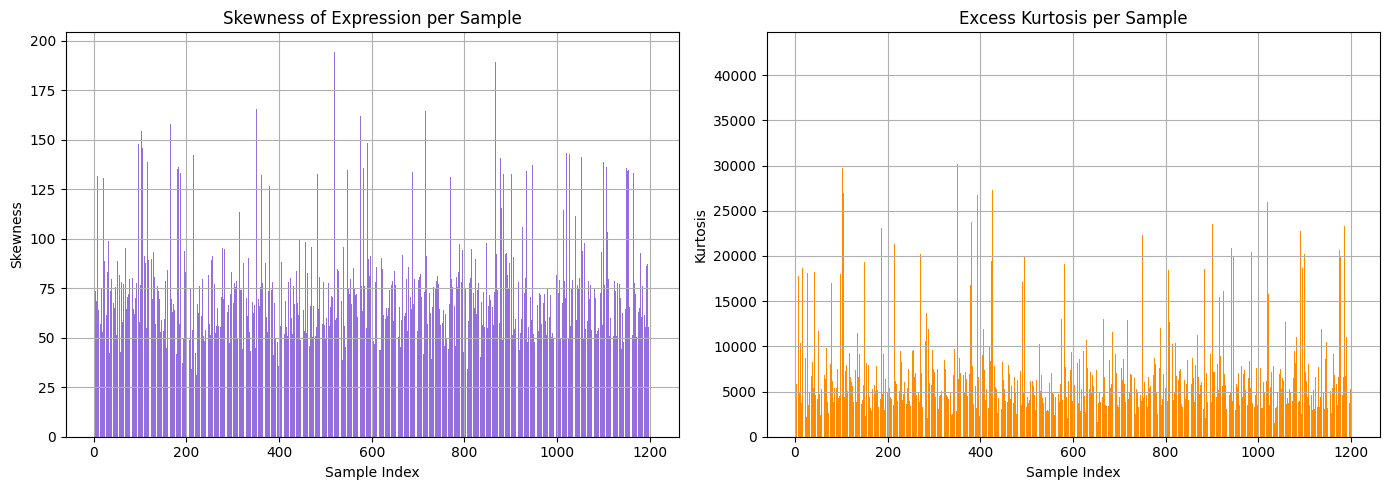

In [17]:
plot_skewness_kurtosis(data=mRNA_data,axis = 0)

### Skewness and Kurtosis Results

In this dataset, both **skewness** and **excess kurtosis** are positive across samples.

This indicates that the gene expression distributions are generally **right-skewed** and exhibit **sharper peaks with heavier tails** than a normal distribution. Such patterns are consistent with typical RNA-seq data, particularly in raw or RPKM-normalized form, and highlight the need for appropriate transformation or normalization in downstream analyses.


## Gene analysis and filtering

Max total counts: 17807169.38 - Min: 0.00 = Range: 17807169.38
Max mean: 14802.30 - Min: 0.00 = Range: 14802.30
Max median: 7129.94 - Min: 0.00 = Range: 7129.94
Max standard deviation: 79947.29 - Min: 0.00 = Range: 79947.29
Max coefficient of variation: 34.68 - Min: 0.27 = Range: 34.42
Max total features: 1203.00 - Min: 0.00 = Range: 1203.00


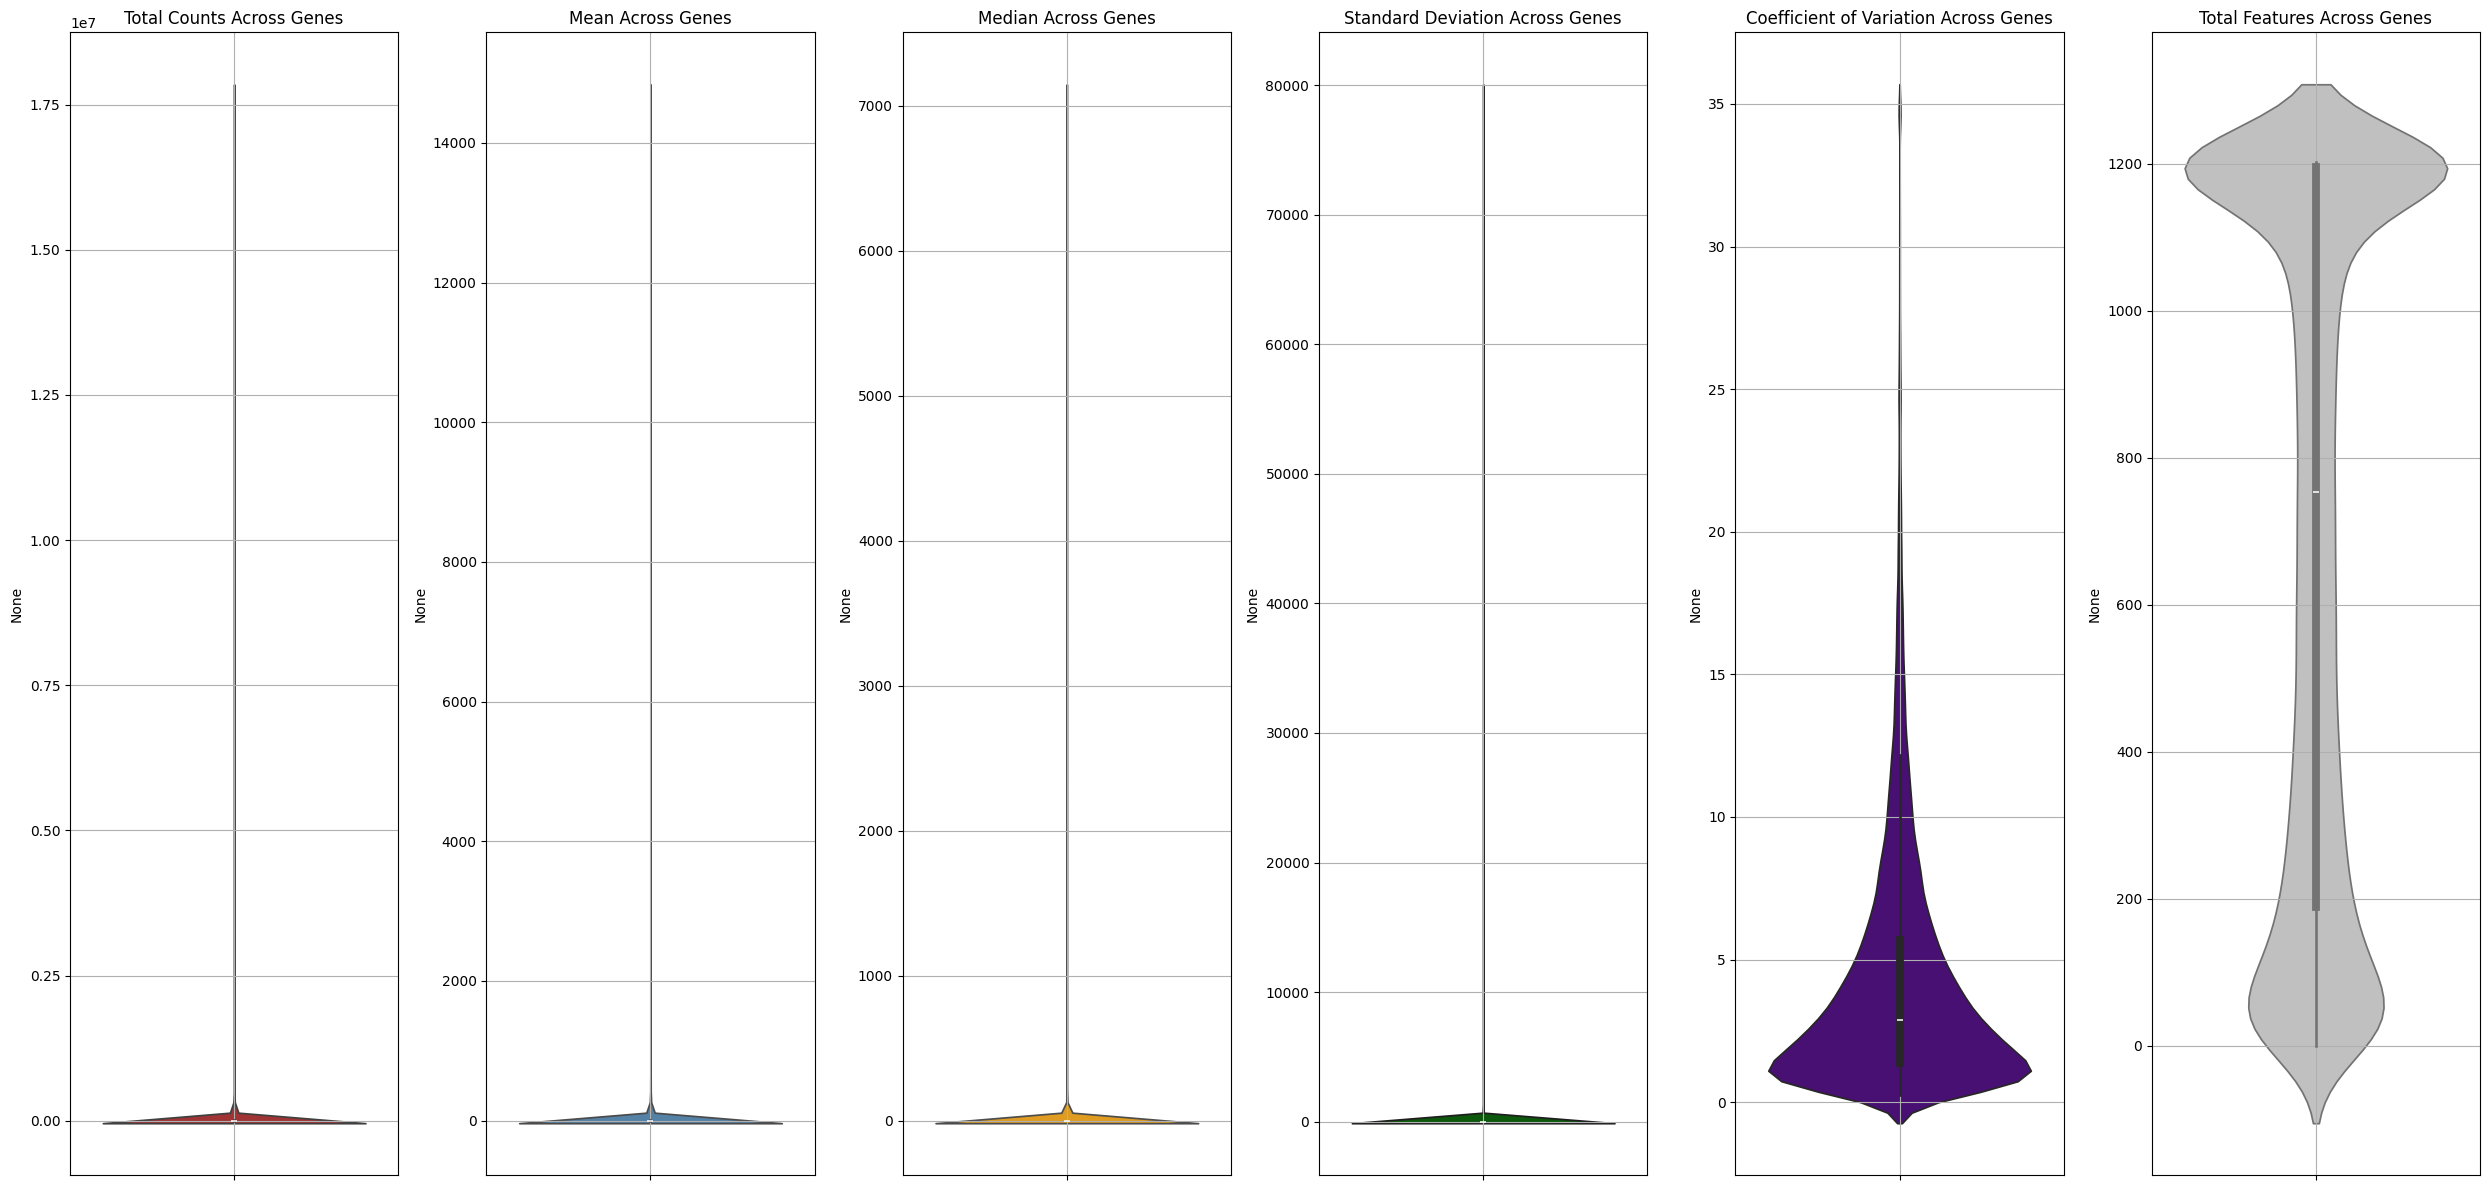

In [18]:
# Violin metrics per gene 
plot_violin_metrics(mRNA_data,axis = 1)

The **coefficient of variation (CV)** shows substantial variability across genes, ranging from ~0.27 to ~34.7. This wide spread indicates that some genes have **nearly constant expression**, while others exhibit **extreme variation** relative to their mean expression levels.

Such extremes can introduce noise or reduce the robustness of downstream analyses. Therefore, it is appropriate to apply a **filtering step** to remove genes with **very low or very high CV**, retaining only those with a moderate and informative level of variation.


In [19]:
# Filter out genes with a coefficient of variation less than 5%
# If gene expression does not vary much compared to the mean, then it is probably less significant to our analysis.

cv_genes = mRNA_data.std(axis = 1)/mRNA_data.mean(axis = 1) 
genes_to_keep = cv_genes[(cv_genes > 0.05) & (cv_genes< 50)].index

# remove
mRNA_final = mRNA_data.loc[genes_to_keep]

We can now see if filtering has had a significant impact on the samples and genes.

Max total counts: 17807169.38 - Min: 0.00 = Range: 17807169.37
Max mean: 14802.30 - Min: 0.00 = Range: 14802.30
Max median: 7129.94 - Min: 0.00 = Range: 7129.94
Max standard deviation: 79947.29 - Min: 0.00 = Range: 79947.29
Max coefficient of variation: 34.68 - Min: 0.27 = Range: 34.42
Max total features: 1203.00 - Min: 1.00 = Range: 1202.00


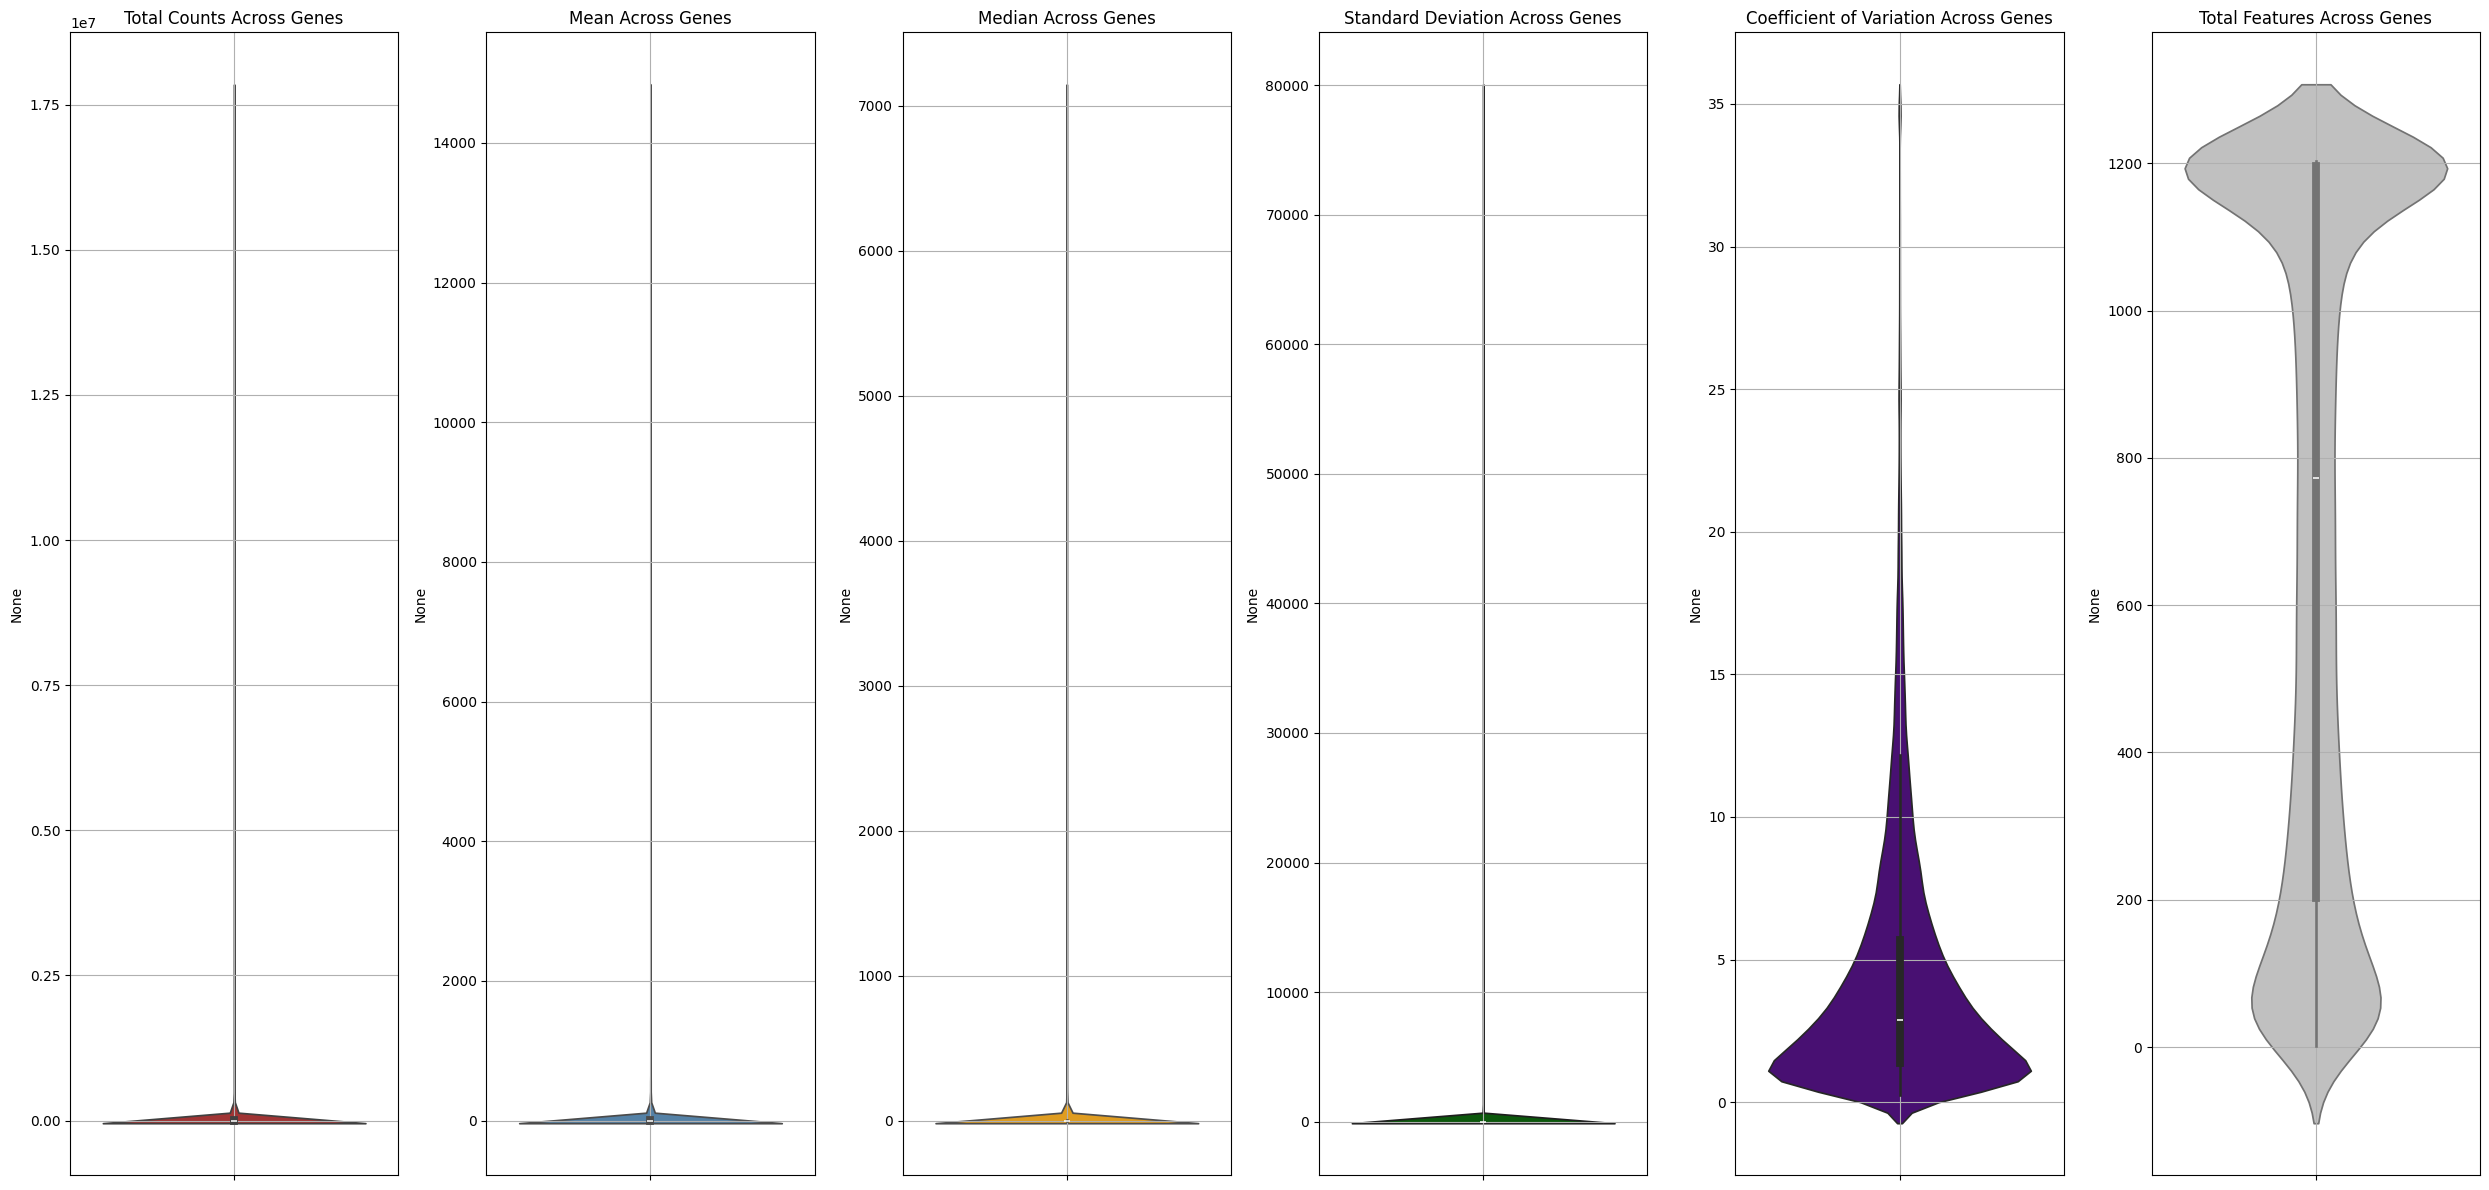

In [20]:
plot_violin_metrics(mRNA_final,axis = 1)

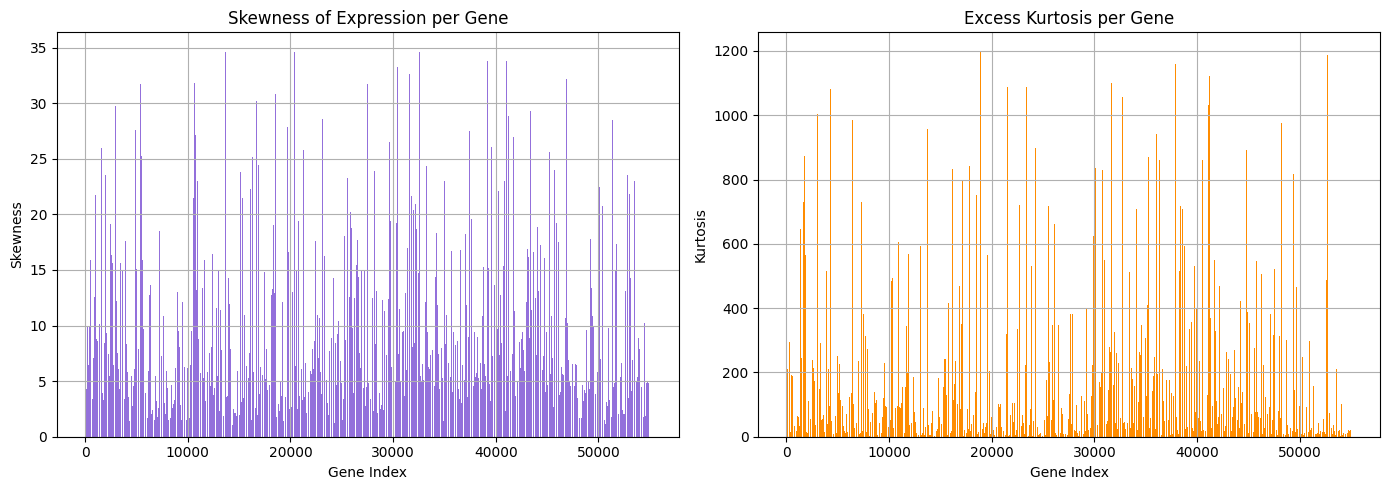

In [21]:
plot_skewness_kurtosis(mRNA_final,axis = 1)

Max total counts: 4252383.31 - Min: 221125.11 = Range: 4031258.20
Max mean: 77.20 - Min: 4.01 = Range: 73.19
Max median: 0.83 - Min: 0.00 = Range: 0.83
Max standard deviation: 9658.20 - Min: 27.17 = Range: 9631.04
Max coefficient of variation: 125.10 - Min: 6.57 = Range: 118.53
Max total features: 51945.00 - Min: 20701.00 = Range: 31244.00


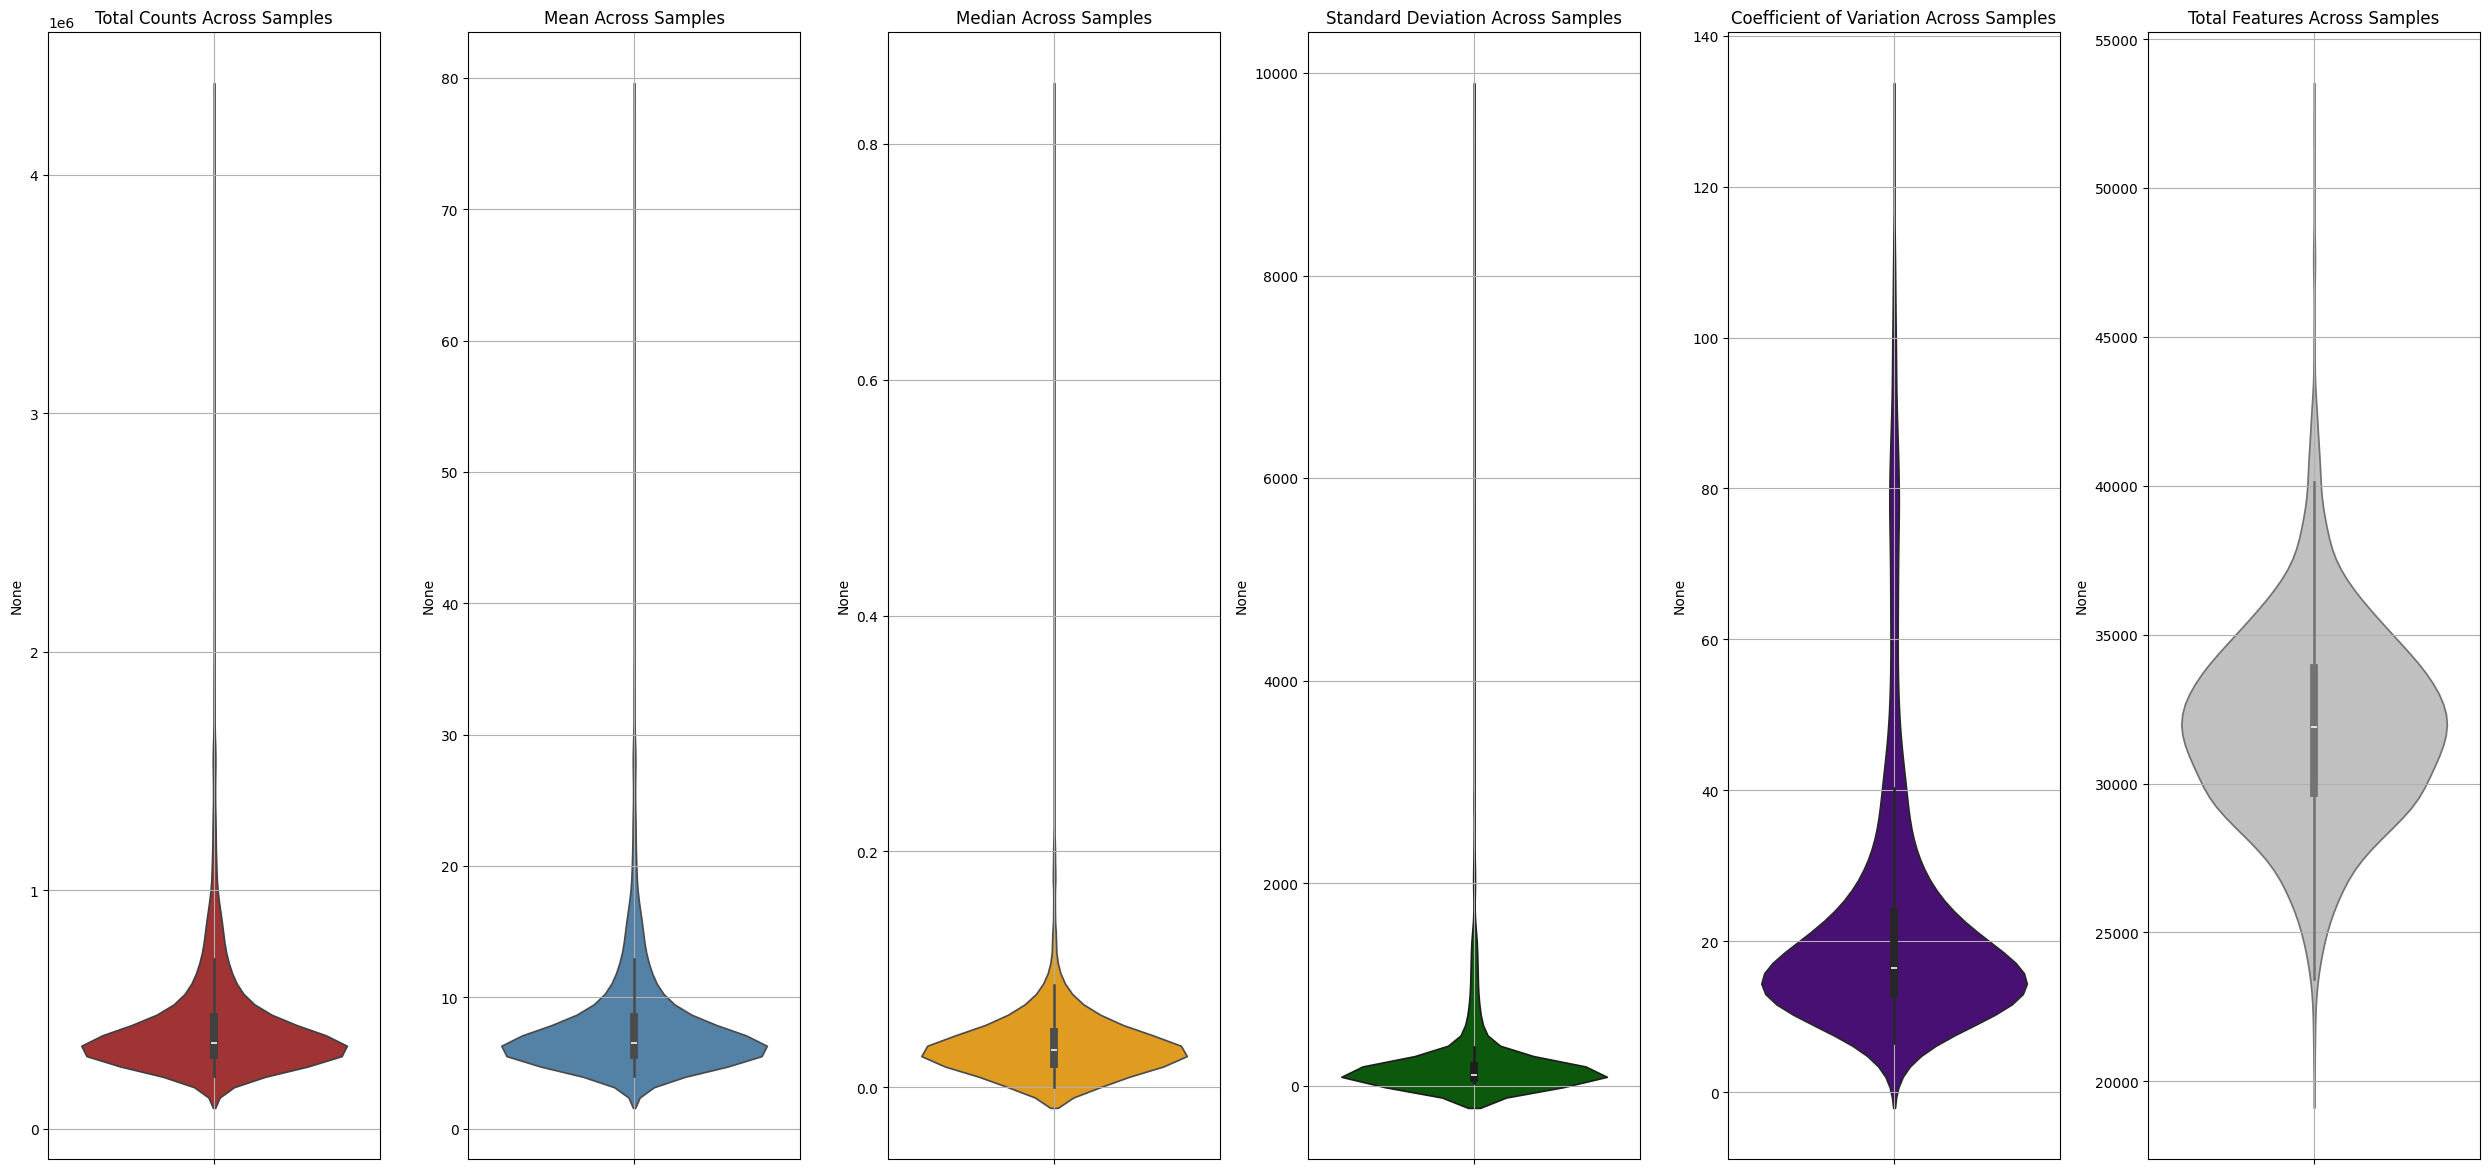

In [22]:
# See how it affected the samples
plot_violin_metrics(mRNA_final,axis = 0)

## Dimensionality Reduction

This section applies dimensionality reduction techniques to visualize the structure of the data and assess whether **mutated** and **non-mutated** samples exhibit any meaningful separation in lower-dimensional space.


In [23]:
mRNA_data_all = mRNA_final[mutated_samples.tolist() + non_mutated_samples.tolist()]

In [24]:
plot_PCA_tsne(mRNA_data_all,mutated_samples,non_mutated_samples,'PCA and TSNE for mRNA data')

ValueError: operands could not be broadcast together with shapes (395,) (803,) 

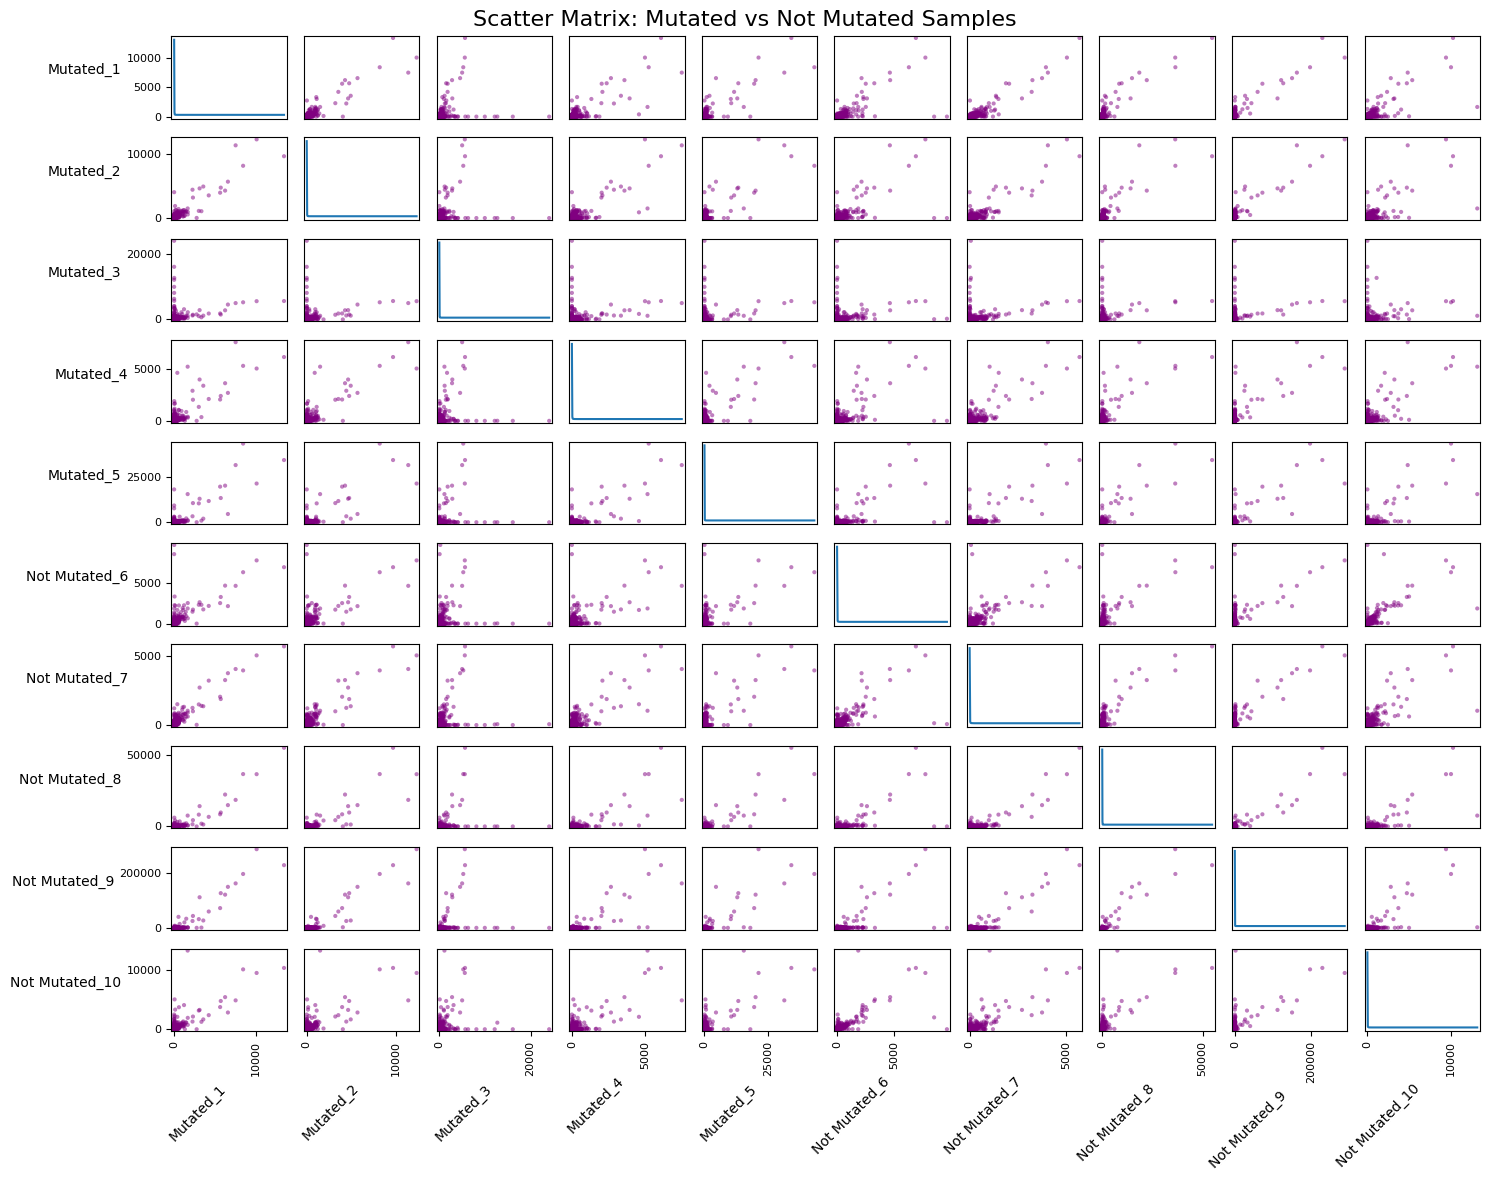

In [25]:
sample_ids = random_samples_mut_100[:5].tolist() + random_samples_non_mut_100[:5].tolist()
sample_mut_non_mut = mRNA_data.loc[:, sample_ids]

# Rename columns to clearer labels
new_labels = ['Mutated'] * 5 + ['Not Mutated'] * 5
sample_mut_non_mut.columns = [f"{label}_{i+1}" for i, label in enumerate(new_labels)]
axes = scatter_matrix(sample_mut_non_mut, diagonal='kde', figsize=(15, 12), color='purple')

# Rotate x and y axis labels for all subplots
for ax in axes.ravel():
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel(), rotation=45, ha='right')
        ax.set_ylabel(ax.get_ylabel(), rotation=0, ha='right')

plt.suptitle("Scatter Matrix: Mutated vs Not Mutated Samples", fontsize=16)
plt.tight_layout()
plt.show()

## Dataset Building

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split

In [29]:
data= pd.read_csv('../DATA/tcga/final_mrna_data.csv', index_col='Hugo_Symbol')
data.head()

X = data.T
X.head()

mutations = pd.read_csv('../DATA/tcga/final_mutation_data.csv', index_col=0)
mutations.head()

y = mutations['Variant_Type']

In [30]:
# Check that X and y are aligned with the same samples in the same order
assert all(X.index == y.index), "Sample mismatch between features and labels!"


# Train/test split
X_train, X_test, y_train_initial, y_test_initial = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

y_train = y_train_initial.map(lambda x: 0 if x == 'WT' else 1)
y_test = y_test_initial.map(lambda x: 0 if x == 'WT' else 1)

print(f"Training data shape: {X_train.shape}")
print(f"Training labels distribution: {y_train.value_counts()}")
print()
print(f"Testing data shape: {X_test.shape}")
print(f"Testing labels distribution: {y_test.value_counts()}")

Training data shape: (962, 55851)
Training labels distribution: Variant_Type
0    642
1    320
Name: count, dtype: int64

Testing data shape: (241, 55851)
Testing labels distribution: Variant_Type
0    161
1     80
Name: count, dtype: int64


In [29]:
print("Train:",X_train.shape)
print("Test:",X_test.shape)
print("Train:",y_train.shape)
print("Test:",y_test.shape)

Train: (962, 55851)
Test: (241, 55851)
Train: (962,)
Test: (241,)


In [31]:
print(y_train_initial.shape)
print(y_test_initial.shape)

(962,)
(241,)


In [ ]:
# Save all the dataframes and arrays
X_train.to_csv('../DATA/tcga/X_train.csv')
X_test.to_csv('../DATA/tcga/X_test.csv')

y_train_initial.to_csv('../DATA/tcga/y_train_initial.csv')
y_test_initial.to_csv('../DATA/tcga/y_test_initial.csv')

y_train.to_csv('../DATA/tcga/y_train.csv')
y_test.to_csv('../DATA/tcga/y_test.csv')
